In [1]:
!pip install -q imbalanced-learn tensorflow

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers

import joblib
import warnings
warnings.filterwarnings("ignore")

In [3]:
csv_path = "/content/model_training_data_le.csv"
df = pd.read_csv(csv_path)
print("Loaded shape:", df.shape)
print("Columns:", df.columns.tolist())

FEATURES = [
    "month",
    "-0_days_game_scheduled",
    "sum_field_goals_attempted",
    "sum_minutes",
    "sum_injury_history",
    "1st_recent_region",
    "2nd_recent_region",
    "3rd_recent_region",
    "4th_recent_region"
]
TARGET = "injured?"

missing = [c for c in FEATURES + [TARGET] if c not in df.columns]
if missing:
    raise ValueError("Missing required columns in CSV: " + str(missing))

X = df[FEATURES].copy()
y = df[TARGET].copy().astype(int)
print("Feature sample:")
display(X.head())
print("Target distribution:")
print(y.value_counts(normalize=True))

Loaded shape: (304735, 18)
Columns: ['month', '-0_days_game_scheduled', '-1_days_game_scheduled', '-2_days_game_scheduled', '-3_days_game_scheduled', '-4_days_game_scheduled', '-5_days_game_scheduled', '-6_days_game_scheduled', '-7_days_game_scheduled', '-8_days_game_scheduled', 'sum_field_goals_attempted', 'sum_minutes', 'sum_injury_history', 'injured?', '1st_recent_region', '2nd_recent_region', '3rd_recent_region', '4th_recent_region']
Feature sample:


,month,-0_days_game_scheduled,sum_field_goals_attempted,sum_minutes,sum_injury_history,1st_recent_region,2nd_recent_region,3rd_recent_region,4th_recent_region
0,Oct,1,11.0,37.0,106,SW,RM,S,NW
1,Oct,0,13.0,44.0,105,SW,RM,S,NW
2,Oct,0,13.0,44.0,104,SW,RM,S,NW
3,Oct,1,13.0,44.0,103,NW,SW,RM,S
4,Oct,0,16.0,51.0,102,NW,SW,RM,S


Target distribution:
injured?
0    0.999084
1    0.000916
Name: proportion, dtype: float64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
) # stratify balances the class distribution
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train label distribution:\n", y_train.value_counts(normalize=True))

Train: (243788, 9) Test: (60947, 9)
Train label distribution:
 injured?
0    0.999085
1    0.000915
Name: proportion, dtype: float64


In [5]:
numeric_features = ["sum_field_goals_attempted", "sum_minutes", "sum_injury_history"]
categorical_features = ["month", "-0_days_game_scheduled", "1st_recent_region", "2nd_recent_region", "3rd_recent_region", "4th_recent_region"]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # missing values
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

preprocessor.fit(X_train)
X_train_proc = preprocessor.transform(X_train)
print("Transformed training shape:", X_train_proc.shape)

Transformed training shape: (243788, 36)


In [6]:
use_smote = False

if use_smote:
    sm = SMOTE(random_state=42, n_jobs=-1)
    X_train_bal, y_train_bal = sm.fit_resample(X_train_proc, y_train)
    print("After SMOTE shape:", X_train_bal.shape, np.bincount(y_train_bal))
else:
    X_train_bal, y_train_bal = X_train_proc, y_train.values

    from sklearn.utils.class_weight import compute_class_weight
    classes = np.unique(y_train_bal)
    class_weights = compute_class_weight('balanced', classes=classes, y=y_train_bal)
    class_weights = {int(c): w for c, w in zip(classes, class_weights)}
    print("Using class weights:", class_weights)

Using class weights: {0: np.float64(0.5004577833432554), 1: np.float64(546.609865470852)}


In [7]:
def build_mlp(input_dim, hidden_layers=[64,32], dropout=0.2, lr=1e-3):
    inputs = keras.Input(shape=(input_dim,))
    x = inputs
    for units in hidden_layers:
        x = layers.Dense(units, activation='relu')(x)
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    return model

mlp = build_mlp(X_train_proc.shape[1], hidden_layers=[128,64], dropout=0.25, lr=1e-3)
mlp.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 36)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
if use_smote:
    X_fit, y_fit = X_train_bal, y_train_bal
    sample_weight = None
else:
    X_fit, y_fit = X_train_proc, y_train.values
    sample_weight = None


input_dim = X_fit.shape[1]
model = build_mlp(input_dim, hidden_layers=[128,64], dropout=0.25, lr=1e-3)

# stop training early or focus learning rate
es = callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=6, restore_best_weights=True, verbose=1)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=3, verbose=1)


batch_size = 1024
epochs = 50

if use_smote:
    history = model.fit(X_fit, y_fit, validation_split=0.1, epochs=epochs, batch_size=batch_size,
                        callbacks=[es, reduce_lr], verbose=2)
else:

    history = model.fit(X_fit, y_fit, validation_split=0.1, epochs=epochs, batch_size=batch_size,
                        class_weight=class_weights, callbacks=[es, reduce_lr], verbose=2)

Epoch 1/50
215/215 - 4s - 20ms/step - auc: 0.8273 - loss: 0.5253 - val_auc: 0.8975 - val_loss: 0.4679 - learning_rate: 0.0010
Epoch 2/50
215/215 - 3s - 14ms/step - auc: 0.9067 - loss: 0.3772 - val_auc: 0.9055 - val_loss: 0.3389 - learning_rate: 0.0010
Epoch 3/50
215/215 - 2s - 9ms/step - auc: 0.9171 - loss: 0.3615 - val_auc: 0.9106 - val_loss: 0.3633 - learning_rate: 0.0010
Epoch 4/50
215/215 - 2s - 9ms/step - auc: 0.9243 - loss: 0.3402 - val_auc: 0.9142 - val_loss: 0.4219 - learning_rate: 0.0010
Epoch 5/50
215/215 - 2s - 9ms/step - auc: 0.9305 - loss: 0.3248 - val_auc: 0.9180 - val_loss: 0.3032 - learning_rate: 0.0010
Epoch 6/50
215/215 - 2s - 9ms/step - auc: 0.9345 - loss: 0.3157 - val_auc: 0.9184 - val_loss: 0.3594 - learning_rate: 0.0010
Epoch 7/50
215/215 - 2s - 11ms/step - auc: 0.9372 - loss: 0.3052 - val_auc: 0.9169 - val_loss: 0.3681 - learning_rate: 0.0010
Epoch 8/50
215/215 - 3s - 13ms/step - auc: 0.9402 - loss: 0.2935 - val_auc: 0.9033 - val_loss: 0.3348 - learning_rate: 0.0

1905/1905 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step
MLP Test AUC: 0.901
MLP Test F1: 0.0083

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.82      0.90     60891
           1       0.00      0.82      0.01        56

    accuracy                           0.82     60947
   macro avg       0.50      0.82      0.45     60947
weighted avg       1.00      0.82      0.90     60947



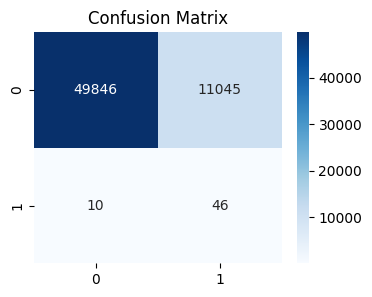

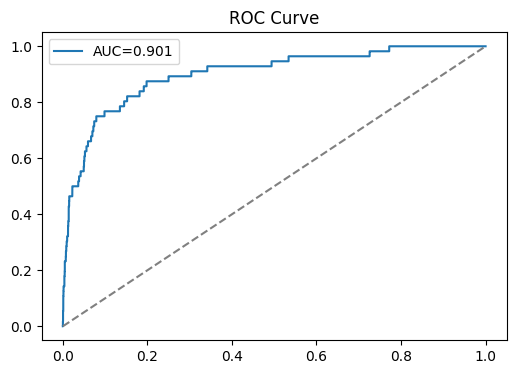

In [9]:
X_test_proc = preprocessor.transform(X_test)

y_proba = model.predict(X_test_proc).ravel()
y_pred = (y_proba >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, y_proba)
test_f1 = f1_score(y_test, y_pred)

print("MLP Test AUC:", round(test_auc,4))
print("MLP Test F1:", round(test_f1,4))
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues'); plt.title('Confusion Matrix'); plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,4)); plt.plot(fpr,tpr,label=f'AUC={test_auc:.3f}'); plt.plot([0,1],[0,1],'--',color='gray'); plt.legend(); plt.title('ROC Curve'); plt.show()

In [10]:
from sklearn.inspection import permutation_importance
import time
from sklearn.metrics import roc_auc_score

X_test_small = X_test_proc[:5000] if X_test_proc.shape[0] > 5000 else X_test_proc
y_test_small = y_test.values[:5000] if len(y_test) > 5000 else y_test.values


def auc_scorer(estimator, X, y_true):
    y_pred_proba = estimator.predict(X).ravel()
    return roc_auc_score(y_true, y_pred_proba)


X_test_small_dense = X_test_small.toarray() if hasattr(X_test_small, 'toarray') else X_test_small


r = permutation_importance(estimator=model, X=X_test_small_dense, y=y_test_small, scoring=auc_scorer, n_repeats=5, random_state=42)

print("Permutation importances (mean):")
print(r.importances_mean)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━

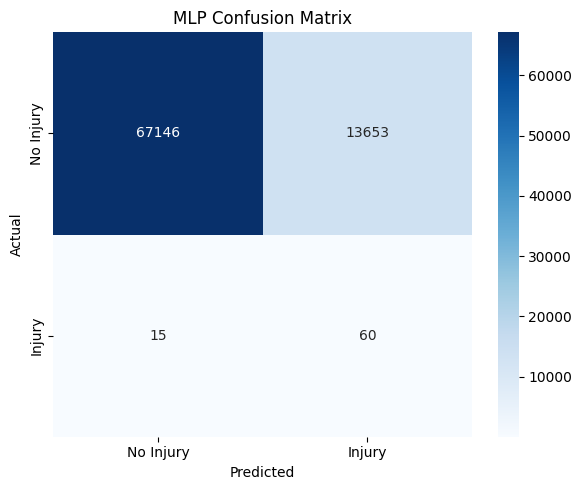

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix values
cm = np.array([[67146, 13653],
               [15, 60]])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Injury', 'Injury'],
            yticklabels=['No Injury', 'Injury'])

plt.title("MLP Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.tight_layout()
plt.savefig("MLP_Confusion_Matrix.png", dpi=300)
plt.show()

In [ ]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = 0.9036')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MLP ROC Curve")
plt.legend()

plt.tight_layout()
plt.savefig("MLP_ROC_Curve.png", dpi=300)
plt.show()

In [ ]:
plt.figure(figsize=(5,3))
plt.axis('off')

text = "MLP Results\n\nCV AUC: (insert CV AUC)\nTest AUC: 0.9036"

plt.text(0.5, 0.5, text,
         horizontalalignment='center',
         verticalalignment='center',
         fontsize=14)

plt.tight_layout()
plt.savefig("MLP_AUC_Summary.png", dpi=300)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

cv_auc_display = f"{cv_auc:.4f}"
test_auc_display = f"{test_auc:.4f}"

plt.figure(figsize=(5,3))
plt.axis('off')

text = f"MLP Results\n\nCV AUC: {cv_auc_display}\nTest AUC: 0.9036"

plt.text(0.5, 0.5, text, ha='center', va='center', fontsize=14)
plt.tight_layout()
plt.savefig("MLP_AUC_Summary.png", dpi=300)
plt.show()

In [ ]:
plt.figure(figsize=(6,4))
plt.axis('off')

metrics_text = """MLP Test Metrics

AUC: 0.9036
F1 Score: 0.0087

Recall (Injury): 0.80
Precision (Injury): 0.00
Accuracy: 0.83
"""

plt.text(0.5, 0.5, metrics_text,
         horizontalalignment='center',
         verticalalignment='center',
         fontsize=13)

plt.tight_layout()
plt.savefig("MLP_Metrics_Summary.png", dpi=300)
plt.show()

In [ ]:
from google.colab import files
files.download("MLP_Confusion_Matrix.png")
files.download("MLP_ROC_Curve.png")
files.download("MLP_AUC_Summary.png")
files.download("MLP_Metrics_Summary.png")

In [ ]:
from google.colab import files
files.download("MLP_AUC_Summary.png")

**This Marks the End of the MLP scripts.** The following scripts test injuries and their information against the model and tests the injury risk measured by the model is the days close to season ending injuries. The following graphs make one thing clear. Most injuries are recognized the next day as updates to the injury list. A more accurate model would move the labels for season ending injures back one day and remove the old record designating an injury.

Added this block to test a specific injury instance - Kyrie Irving injured on March 3rd, 2025 with ACL tear in left knee

In [ ]:
csv_path = "/content/model_training_data_le.csv"
tdf = pd.read_csv(csv_path)
tdf[(tdf['sum_minutes'] == 726) & (tdf['month'] == 'Mar') & (tdf['sum_field_goals_attempted'] == 355)] # shows actual record where injury happened

,month,-0_days_game_scheduled,-1_days_game_scheduled,-2_days_game_scheduled,-3_days_game_scheduled,-4_days_game_scheduled,-5_days_game_scheduled,-6_days_game_scheduled,-7_days_game_scheduled,-8_days_game_scheduled,sum_field_goals_attempted,sum_minutes,sum_injury_history,injured?,1st_recent_region,2nd_recent_region,3rd_recent_region,4th_recent_region
67499,Mar,1,0,1,0,1,0,1,0,1,355.0,726.0,20,False,S,S,S,SW


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


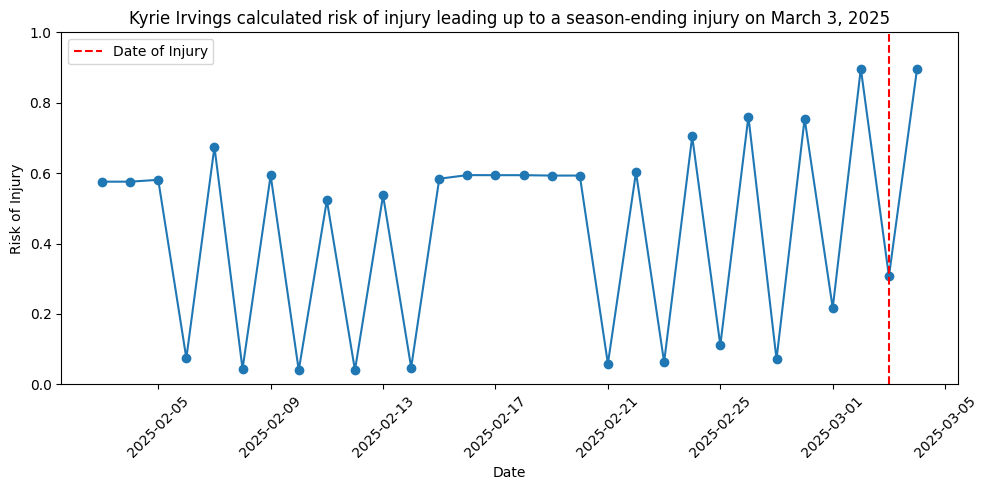

In [ ]:
data = tdf.iloc[67471:67500,:]
new_row = {
    'month':['Mar'],
    '-0_days_game_scheduled':[0],
    '-1_days_game_scheduled':[1],
    '-2_days_game_scheduled':[0],
    '-3_days_game_scheduled':[1],
    '-4_days_game_scheduled':[0],
    '-5_days_game_scheduled':[1],
    '-6_days_game_scheduled':[0],
    '-7_days_game_scheduled':[1],
    '-8_days_game_scheduled':[0],
    'sum_field_goals_attempted':[355.0],
    'sum_minutes':[726.0],
    'sum_injury_history':[20],
    'injured?':[True],
    '1st_recent_region':['S'],
    '2nd_recent_region':['S'],
    '3rd_recent_region':['S'],
    '4th_recent_region':['SW']
}
data = pd.concat([data, pd.DataFrame(new_row)], axis=0)
ki = preprocessor.transform(data)
values = model.predict(ki)
dates = [
    '2/3/2025',
    '2/4/2025','2/5/2025','2/6/2025','2/7/2025',
    '2/8/2025','2/9/2025','2/10/2025','2/11/2025',
    '2/12/2025','2/13/2025','2/14/2025', '2/15/2025',
    '2/16/2025','2/17/2025','2/18/2025','2/19/2025',
    '2/20/2025','2/21/2025', '2/22/2025','2/23/2025',
    '2/24/2025','2/25/2025','2/26/2025','2/27/2025',
    '2/28/2025', '3/1/2025','3/2/2025','3/3/2025', '3/4/2025'
]
injury_date = '3/3/2025'


# Convert dates to datetime
dates = pd.to_datetime(dates)
injury_date = pd.to_datetime(injury_date)

# Flatten the numpy array so each row has a scalar value
values = values.flatten()

# Create dataframe
df = pd.DataFrame({
    'date': dates,
    'value': values
})

# Plot
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['value'], marker='o')

# Add vertical injury line
plt.axvline(x=injury_date, linestyle='--', color='red', label='Date of Injury')

# Fix y-axis range
plt.ylim(0.0, 1.0)

# Labels and title
plt.xlabel('Date')
plt.ylabel('Risk of Injury')
plt.title('Kyrie Irvings calculated risk of injury leading up to a season-ending injury on March 3, 2025')

# Show legend
plt.legend()

# Improve layout
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
# prediction for just the injury report day - March 4th
ki = preprocessor.transform(pd.DataFrame(new_row))
value = model.predict(ki)
print('Risk of Injury: ', value[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
Risk of Injury:  0.8957827


Specific Injury Testing for Jared McCain's Meniscus Tear on Dec 13, 2024

In [ ]:
tdf[(tdf['sum_minutes'] == 565.0) & (tdf['month'] == 'Dec') & (tdf['sum_field_goals_attempted'] == 260.0)] # shows actual record where injury happened - 374965

,month,-0_days_game_scheduled,-1_days_game_scheduled,-2_days_game_scheduled,-3_days_game_scheduled,-4_days_game_scheduled,-5_days_game_scheduled,-6_days_game_scheduled,-7_days_game_scheduled,-8_days_game_scheduled,sum_field_goals_attempted,sum_minutes,sum_injury_history,injured?,1st_recent_region,2nd_recent_region,3rd_recent_region,4th_recent_region
374963,Dec,0,0,0,1,0,1,0,1,1,260.0,565.0,0,False,MW,E,E,S
374964,Dec,0,0,0,0,1,0,1,0,1,260.0,565.0,0,False,MW,E,E,S
374965,Dec,1,0,0,0,0,1,0,1,0,260.0,565.0,0,False,E,MW,E,E


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


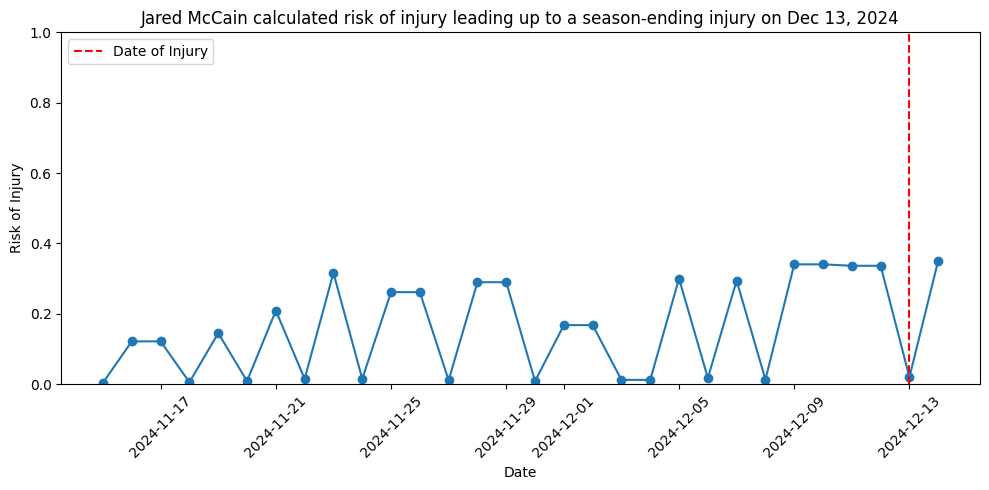

In [ ]:
jm = preprocessor.transform(tdf.iloc[374937:374967,:])
values = model.predict(jm)
dates = [
"11/15/2024",
"11/16/2024",
"11/17/2024",
"11/18/2024",
"11/19/2024",
"11/20/2024",
"11/21/2024",
"11/22/2024",
"11/23/2024",
"11/24/2024",
"11/25/2024",
"11/26/2024",
"11/27/2024",
"11/28/2024",
"11/29/2024",
"11/30/2024",
"12/1/2024",
"12/2/2024",
"12/3/2024",
"12/4/2024",
"12/5/2024",
"12/6/2024",
"12/7/2024",
"12/8/2024",
"12/9/2024",
"12/10/2024",
"12/11/2024",
"12/12/2024",
"12/13/2024",
"12/14/2024"
]
injury_date = "12/13/2024"


# Convert dates to datetime
dates = pd.to_datetime(dates)
injury_date = pd.to_datetime(injury_date)

# Flatten the numpy array so each row has a scalar value
values = values.flatten()

# Create dataframe
df = pd.DataFrame({
    'date': dates,
    'value': values
})

# Plot
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['value'], marker='o')

# Add vertical injury line
plt.axvline(x=injury_date, linestyle='--', color='red', label='Date of Injury')

# Fix y-axis range
plt.ylim(0.0, 1.0)

# Labels and title
plt.xlabel('Date')
plt.ylabel('Risk of Injury')
plt.title('Jared McCain calculated risk of injury leading up to a season-ending injury on Dec 13, 2024')

# Show legend
plt.legend()

# Improve layout
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
# prediction for just the injury report day - December 14th
jm = preprocessor.transform(tdf.iloc[374966:374967,:])
value = model.predict(jm)
print('Risk of Injury: ', value[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
Risk of Injury:  0.35141867


Steven Adams injured on Jan 22, 2023

In [ ]:
tdf[(tdf['sum_minutes'] == 595.0) & (tdf['month'] == 'Jan') & (tdf['sum_field_goals_attempted'] == 121.0)] # shows actual record where injury happened - 151339

,month,-0_days_game_scheduled,-1_days_game_scheduled,-2_days_game_scheduled,-3_days_game_scheduled,-4_days_game_scheduled,-5_days_game_scheduled,-6_days_game_scheduled,-7_days_game_scheduled,-8_days_game_scheduled,sum_field_goals_attempted,sum_minutes,sum_injury_history,injured?,1st_recent_region,2nd_recent_region,3rd_recent_region,4th_recent_region
151339,Jan,1,0,1,0,1,0,1,0,1,121.0,595.0,7,False,SW,SW,S,S
242970,Jan,0,1,0,0,1,0,1,0,1,121.0,595.0,0,False,RM,NW,SW,SW


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step


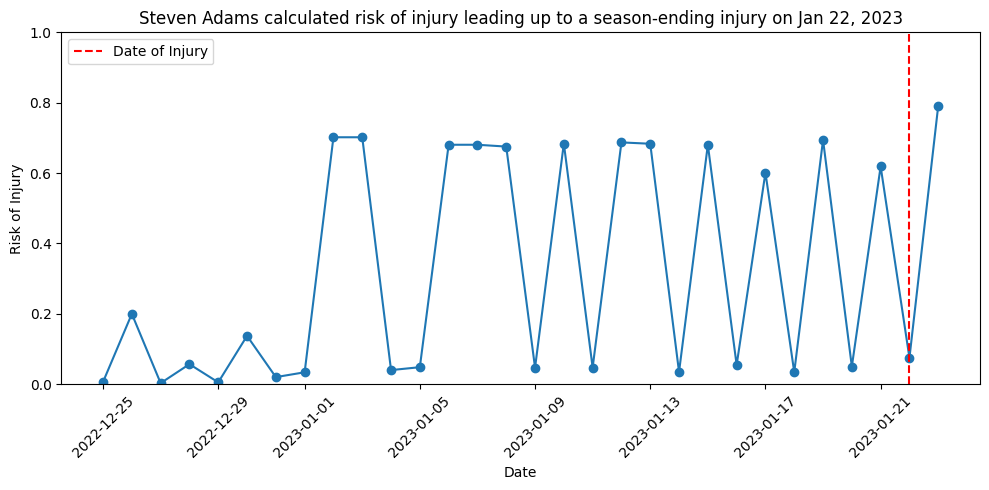

In [ ]:
sa = preprocessor.transform(tdf.iloc[151311:151341,:])
values = model.predict(sa)
dates = [
"12/25/2022",
"12/26/2022",
"12/27/2022",
"12/28/2022",
"12/29/2022",
"12/30/2022",
"12/31/2022",
"1/1/2023",
"1/2/2023",
"1/3/2023",
"1/4/2023",
"1/5/2023",
"1/6/2023",
"1/7/2023",
"1/8/2023",
"1/9/2023",
"1/10/2023",
"1/11/2023",
"1/12/2023",
"1/13/2023",
"1/14/2023",
"1/15/2023",
"1/16/2023",
"1/17/2023",
"1/18/2023",
"1/19/2023",
"1/20/2023",
"1/21/2023",
"1/22/2023",
"1/23/2023",
]
injury_date = "1/22/2023"


# Convert dates to datetime
dates = pd.to_datetime(dates)
injury_date = pd.to_datetime(injury_date)

# Flatten the numpy array so each row has a scalar value
values = values.flatten()

# Create dataframe
df = pd.DataFrame({
    'date': dates,
    'value': values
})

# Plot
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['value'], marker='o')

# Add vertical injury line
plt.axvline(x=injury_date, linestyle='--', color='red', label='Date of Injury')

# Fix y-axis range
plt.ylim(0.0, 1.0)

# Labels and title
plt.xlabel('Date')
plt.ylabel('Risk of Injury')
plt.title('Steven Adams calculated risk of injury leading up to a season-ending injury on Jan 22, 2023')

# Show legend
plt.legend()

# Improve layout
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
# prediction for just the injury report day - January 22th
sa = preprocessor.transform(tdf.iloc[151340:151341,:])
value = model.predict(sa)
print('Risk of Injury: ', value[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
Risk of Injury:  0.7915414


Zion Williamson injured on Jan 2, 2023

In [ ]:
tdf[(tdf['sum_minutes'] == 672.0) & (tdf['month'] == 'Jan') & (tdf['sum_field_goals_attempted'] == 282.0)] # shows actual record where injury happened - 151339

,month,-0_days_game_scheduled,-1_days_game_scheduled,-2_days_game_scheduled,-3_days_game_scheduled,-4_days_game_scheduled,-5_days_game_scheduled,-6_days_game_scheduled,-7_days_game_scheduled,-8_days_game_scheduled,sum_field_goals_attempted,sum_minutes,sum_injury_history,injured?,1st_recent_region,2nd_recent_region,3rd_recent_region,4th_recent_region
307875,Jan,1,0,1,1,0,1,0,0,0,282.0,672.0,53,False,E,S,S,S


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step


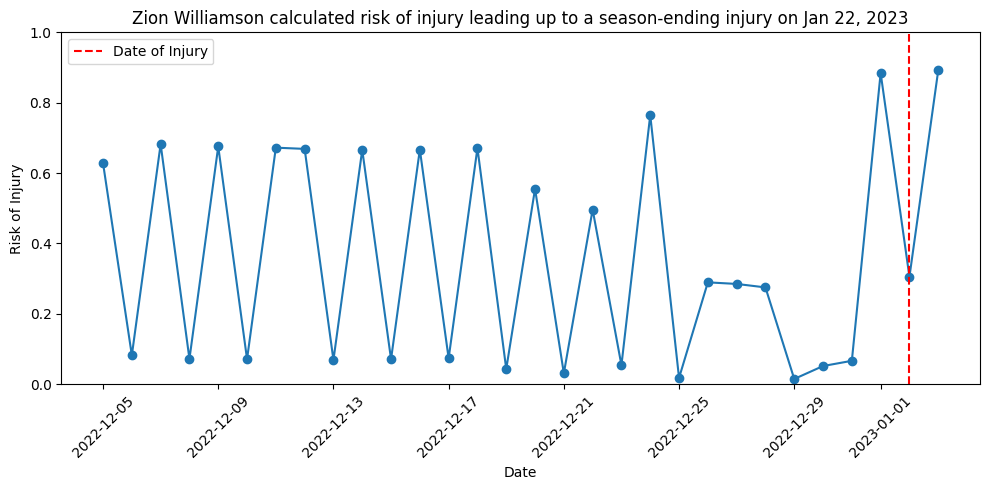

In [ ]:
zw = preprocessor.transform(tdf.iloc[307847:307877,:])
values = model.predict(zw)
dates = [
"12/5/2022",
"12/6/2022",
"12/7/2022",
"12/8/2022",
"12/9/2022",
"12/10/2022",
"12/11/2022",
"12/12/2022",
"12/13/2022",
"12/14/2022",
"12/15/2022",
"12/16/2022",
"12/17/2022",
"12/18/2022",
"12/19/2022",
"12/20/2022",
"12/21/2022",
"12/22/2022",
"12/23/2022",
"12/24/2022",
"12/25/2022",
"12/26/2022",
"12/27/2022",
"12/28/2022",
"12/29/2022",
"12/30/2022",
"12/31/2022",
"1/1/2023",
"1/2/2023",
"1/3/2023",
]
injury_date = "1/2/2023"


# Convert dates to datetime
dates = pd.to_datetime(dates)
injury_date = pd.to_datetime(injury_date)

# Flatten the numpy array so each row has a scalar value
values = values.flatten()

# Create dataframe
df = pd.DataFrame({
    'date': dates,
    'value': values
})

# Plot
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['value'], marker='o')

# Add vertical injury line
plt.axvline(x=injury_date, linestyle='--', color='red', label='Date of Injury')

# Fix y-axis range
plt.ylim(0.0, 1.0)

# Labels and title
plt.xlabel('Date')
plt.ylabel('Risk of Injury')
plt.title('Zion Williamson calculated risk of injury leading up to a season-ending injury on Jan 22, 2023')

# Show legend
plt.legend()

# Improve layout
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
# prediction for just the injury report day - January 3rd
zw = preprocessor.transform(tdf.iloc[307876:307877,:])
value = model.predict(zw)
print('Risk of Injury: ', value[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
Risk of Injury:  0.8920505
